<a href="https://colab.research.google.com/github/DanyRE4020/Concentracion_IA_avanzada/blob/main/Notebook5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data_2024 = pd.read_csv('/content/contaminantes_2024.csv', sep=',',skiprows=9,encoding="utf-8")
data_2025 = pd.read_csv('/content/contaminantes_2025.csv',sep=',', skiprows=9,encoding="utf-8")
data_2026 = pd.read_csv('/content/contaminantes_2026.csv', sep=',',skiprows=9,encoding="utf-8")
data_2024.columns = ["date", "id_station", "id_parameter", "value", "unit"]
data_2025.columns = ["date", "id_station", "id_parameter", "value", "unit"]
data_2026.columns = ["date", "id_station", "id_parameter", "value", "unit"]

In [37]:
# Concatenarlos en un solo df
data = pd.concat(
    [data_2024, data_2025, data_2026],
    ignore_index=True
)

data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["value"] = pd.to_numeric(data["value"], errors="coerce")

data

,date,id_station,id_parameter,value,unit
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0
...,...,...,...,...,...
5394148,2026-02-28 23:00:00,XAL,O3,NaN,1.0
5394149,2026-02-28 23:00:00,XAL,PM10,NaN,2.0
5394150,2026-02-28 23:00:00,XAL,PM2.5,NaN,2.0
5394151,2026-02-28 23:00:00,XAL,PMCO,NaN,2.0


In [38]:
# Separar día de horas
data["fecha"] = data["date"].dt.strftime("%Y-%m-%d")
data["hora"] = data["date"].dt.strftime("%H:%M:%S")

data = data.drop(columns=["date"])

data

,id_station,id_parameter,value,unit,fecha,hora
0,ACO,CO,NaN,15.0,2024-01-01,01:00:00
1,ACO,NO,NaN,1.0,2024-01-01,01:00:00
2,ACO,NO2,NaN,1.0,2024-01-01,01:00:00
3,ACO,NOX,NaN,1.0,2024-01-01,01:00:00
4,ACO,O3,NaN,1.0,2024-01-01,01:00:00
...,...,...,...,...,...,...
5394148,XAL,O3,NaN,1.0,2026-02-28,23:00:00
5394149,XAL,PM10,NaN,2.0,2026-02-28,23:00:00
5394150,XAL,PM2.5,NaN,2.0,2026-02-28,23:00:00
5394151,XAL,PMCO,NaN,2.0,2026-02-28,23:00:00


In [39]:
# Eliminar na
data = data.dropna()
data

,id_station,id_parameter,value,unit,fecha,hora
7,AJM,CO,0.23,15.0,2024-01-01,01:00:00
8,AJM,NO,0.00,1.0,2024-01-01,01:00:00
9,AJM,NO2,10.00,1.0,2024-01-01,01:00:00
10,AJM,NOX,10.00,1.0,2024-01-01,01:00:00
11,AJM,O3,43.00,1.0,2024-01-01,01:00:00
...,...,...,...,...,...,...
5394131,UIZ,PM10,42.00,2.0,2026-02-28,23:00:00
5394132,UIZ,PM2.5,16.00,2.0,2026-02-28,23:00:00
5394133,UIZ,PMCO,26.00,2.0,2026-02-28,23:00:00
5394135,VIF,CO,0.80,15.0,2026-02-28,23:00:00


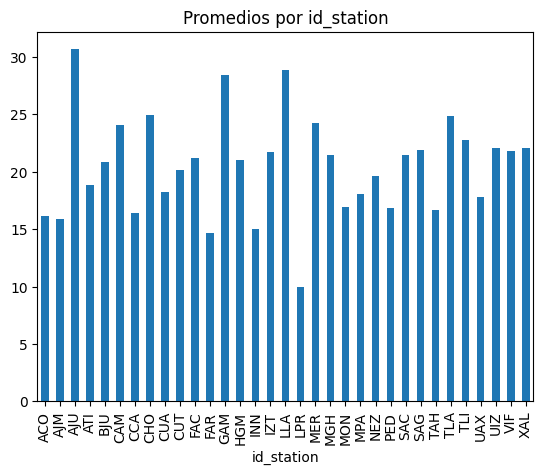

In [44]:
# Calcular Medidas de Tendencia Central
# Por id_station
mean_values = data.groupby("id_station")["value"].mean()
median_values = data.groupby("id_station")["value"].median()
mode_values = data.groupby("id_station")["value"].agg(pd.Series.mode)

# Graficar promedios por id_station
mean_values.plot(kind="bar", title="Promedios por id_station")
plt.show()